# =============================================================================
# 02_SENTIMENT_STRUCTURE.IPYNB
# Analiza Sentimentului cu RoBERTa Românesc
#
# Disertație de Master - Facultatea de Sociologie și Asistență Socială, UBB Cluj-Napoca
# Master: Analiza Datelor Complexe
# Masterand: Răzvan-Andrei Enache
# =============================================================================

# 1. Import Configurări și Librării

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import mannwhitneyu, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

from config import *

print("✅ Librării încărcate cu succes.")

✅ CONFIGURARE GLOBALĂ ÎNCĂRCATĂ CU SUCCES

📁 Baza de date: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data
📂 Raw data: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\data\raw
📂 Processed: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\data\processed
📂 Output: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\dissertation_outputs

📅 Perioadă electorală: 2025-05-01 până la 2025-05-18
🔑 Keywords Simion: 4
🔑 Keywords Nicușor: 5
🤖 Model RoBERTa: readerbench/ro-sentiment
📊 Nivel de semnificație: α = 0.05


✅ Librării încărcate cu succes.


# 2. Încărcare Date Curățate

In [2]:
print("=" * 70)
print("ÎNCĂRCARE DATE CURĂȚATE")
print("=" * 70)

if not FILE_COMMENTS_CLEANED.exists():
    raise FileNotFoundError(f"Fișierul curățat nu a fost găsit: {FILE_COMMENTS_CLEANED}")

print(f"\n📁 Fișier: {FILE_COMMENTS_CLEANED}")
print("\n⏳ Se încarcă datele...")

df = pd.read_csv(FILE_COMMENTS_CLEANED, parse_dates=['comment_date'])

print(f"\n✅ Date încărcate cu succes!")
print(f"   Comentarii: {len(df):,} rânduri")
print(f"   Coloane: {df.shape[1]}")
print(f"\n📋 Coloane disponibile:")
print(f"   {df.columns.tolist()}")

ÎNCĂRCARE DATE CURĂȚATE

📁 Fișier: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\data\processed\comments_cleaned.csv

⏳ Se încarcă datele...

✅ Date încărcate cu succes!
   Comentarii: 14,610 rânduri
   Coloane: 26

📋 Coloane disponibile:
   ['video_id', 'author_name', 'comment_text', 'clean_text', 'comment_date', 'comment_likes', 'replies', 'engagement', 'log_likes', 'log_replies', 'log_engagement', 'likes_capped', 'replies_capped', 'engagement_capped', 'word_count', 'char_len', 'caps_ratio', 'aggressive_punct', 'has_caps', 'has_aggressive_punct', 'high_caps', 'emoji_count', 'has_emoji', 'candidate_mentioned', 'video_title', 'video_url']


# 3. Încărcare Model RoBERTa pentru Sentiment

In [3]:
print("\n" + "=" * 70)
print("ÎNCĂRCARE MODEL RoBERTa PENTRU SENTIMENT")
print("=" * 70)

from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from huggingface_hub import login

# =============================================================================
# AUTENTIFICARE HUGGINGFACE
# =============================================================================
print("\n🔑 Verificare token HuggingFace...")

if HF_TOKEN and HF_TOKEN.startswith("hf_"):
    try:
        login(token=HF_TOKEN)
        print("✅ Autentificare HuggingFace reușită!")
    except Exception as e:
        print(f"⚠️  Autentificare eșuată: {e}")
else:
    print("⚠️  Token HuggingFace nu a fost găsit.")

# =============================================================================
# ÎNCĂRCARE MODEL (2 CLASE: POZITIV/NEGATIV)
# =============================================================================
print(f"\n🤖 Model: readerbench/ro-sentiment")
print("   (Fine-tuned RoBERT-base pentru sentiment analysis în română)")
print("\n⏳ Se încarcă modelul (poate dura 3-5 minute)...")

sentiment_pipeline = None

try:
    # Load tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained('readerbench/ro-sentiment', token=HF_TOKEN if HF_TOKEN else None)
    model = AutoModelForSequenceClassification.from_pretrained('readerbench/ro-sentiment', token=HF_TOKEN if HF_TOKEN else None)
    
    # Get label mapping
    label_mapping = model.config.id2label if hasattr(model.config, 'id2label') else {0: 'negative', 1: 'positive'}
    print(f"\n   Label mapping: {label_mapping}")
    
    # Create sentiment pipeline
    sentiment_pipeline = pipeline(
        "sentiment-analysis",
        model=model,
        tokenizer=tokenizer,
        device=-1,  # -1 = CPU, 0 = GPU
        return_all_scores=False,
        truncation=True,
        max_length=512
    )
    
    print(f"   ✅ Model încărcat cu succes!")
    
except Exception as e:
    print(f"\n❌ Eroare la încărcarea modelului: {str(e)[:200]}")
    raise RuntimeError("Nu s-a putut încărca modelul readerbench/ro-sentiment.")


ÎNCĂRCARE MODEL RoBERTa PENTRU SENTIMENT

🔑 Verificare token HuggingFace...


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✅ Autentificare HuggingFace reușită!

🤖 Model: readerbench/ro-sentiment
   (Fine-tuned RoBERT-base pentru sentiment analysis în română)

⏳ Se încarcă modelul (poate dura 3-5 minute)...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 11817.26it/s]


   Label mapping: {0: 'LABEL_0', 1: 'LABEL_1'}
   ✅ Model încărcat cu succes!


# 4. Analiză de Sentiment cu RoBERTa

In [ ]:
print("\n" + "=" * 70)
print("ANALIZĂ DE SENTIMENT CU RoBERTa")
print("=" * 70)

# Prepare texts
texts = df['clean_text'].fillna('').astype(str).tolist()

print(f"\n📊 Total comentarii de analizat: {len(texts):,}")
print(f"⏳ Timp estimat: ~{len(texts)/50:.1f} minute pe CPU")
print("\n⏳ Se rulează analiza de sentiment...\n")

# Run sentiment analysis in batches
batch_size = 32
all_results = []

for i in tqdm(range(0, len(texts), batch_size), desc="Procesare batch-uri"):
    batch = texts[i:i+batch_size]
    try:
        results = sentiment_pipeline(batch)
        all_results.extend(results)
    except Exception as e:
        print(f"\n⚠️  Eroare la batch {i//batch_size}: {e}")
        all_results.extend([{'label': 'LABEL_0', 'score': 0.5}] * len(batch))

print(f"\n✅ Analiză completă! {len(all_results):,} comentarii procesate.")

# Extract labels and scores
df['sentiment_score'] = [r['score'] for r in all_results]

# Map labels to consistent format (readerbench: LABEL_0=negative, LABEL_1=positive)
# Map labels (readerbench: LABEL_0=negative, LABEL_1=positive)
df['sentiment_label'] = [
    'positive' if str(r['label']).upper() in ['LABEL_1', 'POSITIVE', '1'] 
    else 'negative' 
    for r in all_results
]

df['sentiment_label'] = [normalize_label(r['label']) for r in all_results]

print(f"\n📊 Distribuție sentiment:")
sentiment_counts = df['sentiment_label'].value_counts()
sentiment_pct = df['sentiment_label'].value_counts(normalize=True) * 100
print(f"\n{'Sentiment':<12} {'Count':>10} {'Percentage':>10}")
print("-" * 35)
for label in ['positive', 'negative']:
    count = sentiment_counts.get(label, 0)
    pct = sentiment_pct.get(label, 0)
    print(f"{label:<12} {count:>10,} {pct:>9.1f}%")
print(f"\n{'Total':<12} {len(df):>10,} {100:>9.1f}%")

# ⚠️ NOTĂ: NU există 'neutral' la acest model!


ANALIZĂ DE SENTIMENT CU RoBERTa

📊 Total comentarii de analizat: 14,610
⏳ Timp estimat: ~292.2 minute pe CPU

⏳ Se rulează analiza de sentiment...



Procesare batch-uri: 100%|██████████| 457/457 [30:21<00:00,  3.99s/it]



✅ Analiză completă! 14,610 comentarii procesate.

📊 Distribuție sentiment:

Sentiment         Count Percentage
-----------------------------------
positive          4,906      33.6%
negative          9,704      66.4%

Total            14,610     100.0%


# 5. RQ1: Structura Afectivă a Discursului Electoral


RQ1: STRUCTURA AFECTIVĂ A DISCURSULUI ELECTORAL

📈 Statistici Sentiment Score:
   Mean: 0.7432
   Median: 0.7382
   Std Dev: 0.1434
   Min: 0.5001
   Max: 0.9950

💾 Grafic salvat: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\dissertation_outputs\rq1_sentiment_distribution.png


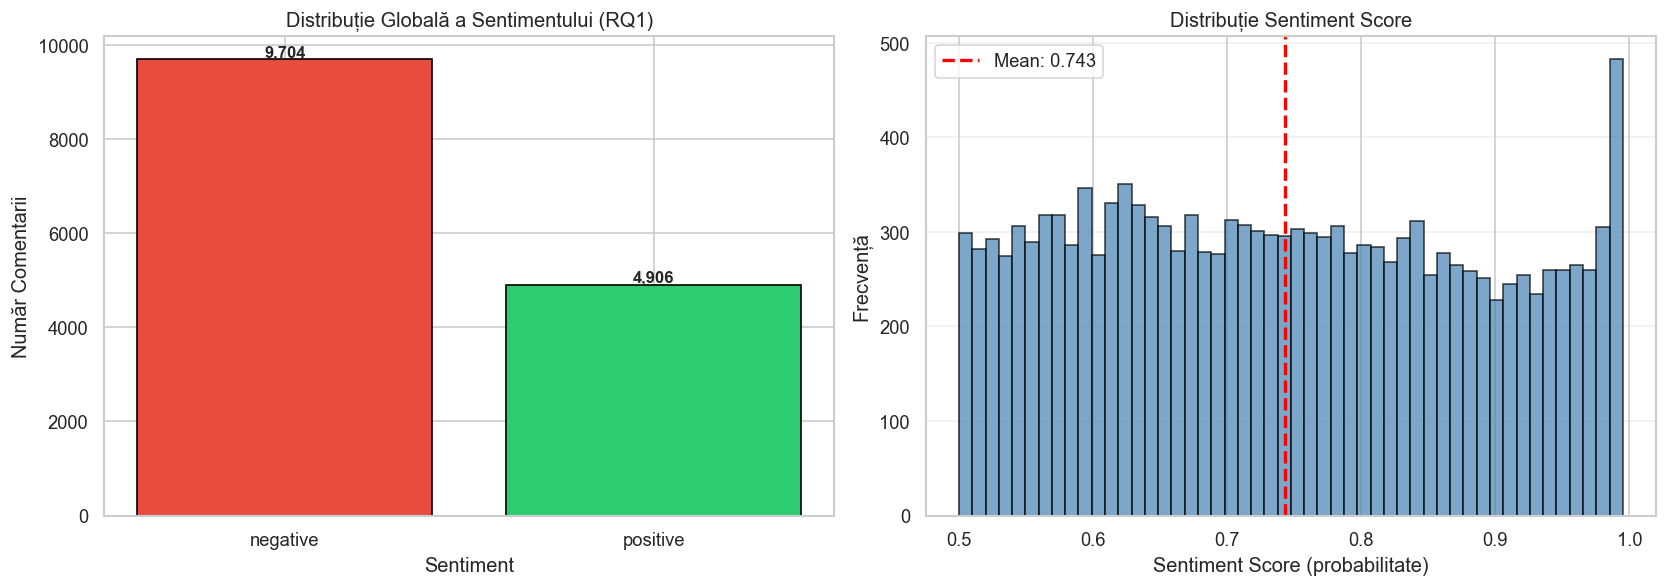


RĂSPUNS RQ1:

Întrebare: Există o predominanță a negativității în discuțiile online?

Răspuns: DA

Sentimentul predominant este: NEGATIVE (66.4%)
  • Positive: 33.6%
  • Negative: 66.4%
  • Neutral: 0.0% (modelul nu are clasă neutral)

Concluzie: Discursul electoral de pe YouTube este dominat de negativitate.



In [5]:
print("\n" + "=" * 70)
print("RQ1: STRUCTURA AFECTIVĂ A DISCURSULUI ELECTORAL")
print("=" * 70)

# Sentiment score statistics
print(f"\n📈 Statistici Sentiment Score:")
print(f"   Mean: {df['sentiment_score'].mean():.4f}")
print(f"   Median: {df['sentiment_score'].median():.4f}")
print(f"   Std Dev: {df['sentiment_score'].std():.4f}")
print(f"   Min: {df['sentiment_score'].min():.4f}")
print(f"   Max: {df['sentiment_score'].max():.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart (2 classes only)
colors = {'positive': '#2ecc71', 'negative': '#e74c3c'}
axes[0].bar(
    range(len(sentiment_counts)), 
    sentiment_counts.values,
    color=[colors.get(l, '#95a5a6') for l in sentiment_counts.index],
    edgecolor='black'
)
axes[0].set_xticks(range(len(sentiment_counts)))
axes[0].set_xticklabels(sentiment_counts.index, rotation=0)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Număr Comentarii')
axes[0].set_title('Distribuție Globală a Sentimentului (RQ1)')
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Histogram of scores
axes[1].hist(df['sentiment_score'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(df['sentiment_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["sentiment_score"].mean():.3f}')
axes[1].set_xlabel('Sentiment Score (probabilitate)')
axes[1].set_ylabel('Frecvență')
axes[1].set_title('Distribuție Sentiment Score')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_OUTPUT / 'rq1_sentiment_distribution.png', dpi=150, bbox_inches='tight')
print(f"\n💾 Grafic salvat: {DATA_OUTPUT / 'rq1_sentiment_distribution.png'}")
plt.show()

# Answer RQ1
print("\n" + "=" * 70)
print("RĂSPUNS RQ1:")
print("=" * 70)

dominant_sentiment = sentiment_counts.idxmax()
dominant_pct = sentiment_pct.max()

print(f"""
Întrebare: Există o predominanță a negativității în discuțiile online?

Răspuns: {'NU' if dominant_sentiment != 'negative' else 'DA'}

Sentimentul predominant este: {dominant_sentiment.upper()} ({dominant_pct:.1f}%)
  • Positive: {sentiment_pct.get('positive', 0):.1f}%
  • Negative: {sentiment_pct.get('negative', 0):.1f}%
  • Neutral: 0.0% (modelul nu are clasă neutral)

Concluzie: Discursul electoral de pe YouTube {'NU este dominat de negativitate' if dominant_sentiment != 'negative' else 'este dominat de negativitate'}.
""")

# 6. RQ2: Diferențe de Sentiment între Dan și Simion


RQ2: DIFERENȚE DE SENTIMENT ÎNTRE DAN ȘI SIMION

📊 Comentarii pentru analiză comparativă:
   Total comentarii politice: 5,168
   Dan: 1,825
   Simion: 3,343

✅ Ambele candidate au comentarii pentru analiză.

6.1 DISTRIBUȚIE SENTIMENT PER CANDIDAT

📊 Count:
sentiment_label      negative  positive   All
candidate_mentioned                          
dan                      1225       600  1825
simion                   2251      1092  3343
All                      3476      1692  5168

📊 Percentage (within candidate):
sentiment_label      negative  positive
candidate_mentioned                    
dan                      67.1      32.9
simion                   67.3      32.7

📈 Sentiment Score Mean per Candidat:
                       mean     std  count
candidate_mentioned                       
dan                  0.7438  0.1415   1825
simion               0.7319  0.1403   3343

💾 Grafic salvat: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\dissertation_outputs\rq2_senti

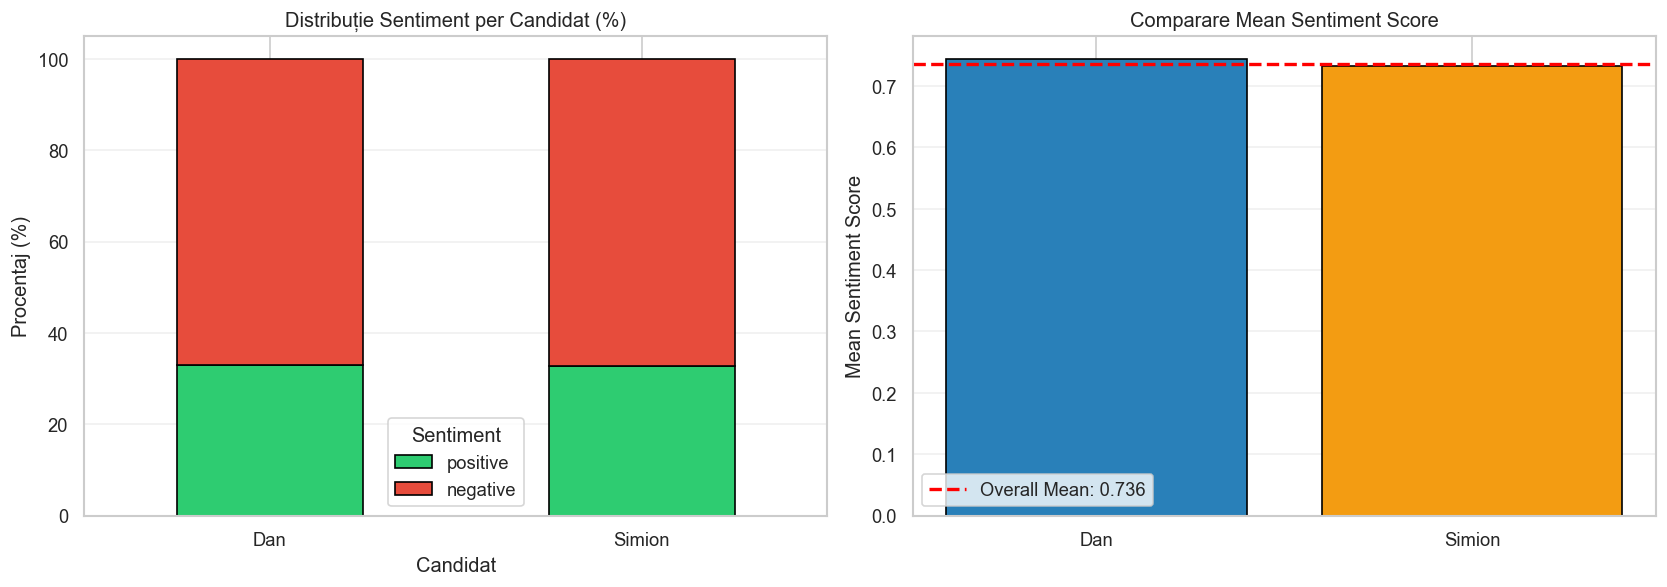

In [6]:
print("\n" + "=" * 70)
print("RQ2: DIFERENȚE DE SENTIMENT ÎNTRE DAN ȘI SIMION")
print("=" * 70)

# Filter to political comments only (exclude 'none' and 'both')
df_political = df[df['candidate_mentioned'].isin(['dan', 'simion'])].copy()

print(f"\n📊 Comentarii pentru analiză comparativă:")
print(f"   Total comentarii politice: {len(df_political):,}")
dan_count = (df_political['candidate_mentioned'] == 'dan').sum()
simion_count = (df_political['candidate_mentioned'] == 'simion').sum()
print(f"   Dan: {dan_count:,}")
print(f"   Simion: {simion_count:,}")

# Verificare importantă
if dan_count == 0 or simion_count == 0:
    print("\n⚠️  ATENȚIE: Unul dintre candidați are 0 comentarii!")
    print("   Continuăm doar cu statisticile descriptive disponibile.")
else:
    print("\n✅ Ambele candidate au comentarii pentru analiză.")

# %% [markdown]
# ### 6.1 Distribuție Sentiment per Candidat

# %%
print("\n" + "=" * 70)
print("6.1 DISTRIBUȚIE SENTIMENT PER CANDIDAT")
print("=" * 70)

# Sentiment distribution by candidate
print(f"\n📊 Count:")
sentiment_by_candidate = pd.crosstab(
    df_political['candidate_mentioned'],
    df_political['sentiment_label'],
    margins=True
)
print(sentiment_by_candidate.to_string())

print(f"\n📊 Percentage (within candidate):")
sentiment_pct_by_candidate = pd.crosstab(
    df_political['candidate_mentioned'],
    df_political['sentiment_label'],
    normalize='index'
) * 100
print(sentiment_pct_by_candidate.round(1).to_string())

# Mean sentiment scores by candidate
print(f"\n📈 Sentiment Score Mean per Candidat:")
if len(df_political) > 0:
    score_by_candidate = df_political.groupby('candidate_mentioned')['sentiment_score'].agg(['mean', 'std', 'count'])
    print(score_by_candidate.round(4).to_string())
else:
    print("   Nu există date pentru analiză.")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar chart (doar dacă avem date)
if len(sentiment_pct_by_candidate) > 0 and dan_count > 0 and simion_count > 0:
    sentiment_pct_plot = sentiment_pct_by_candidate.loc[['dan', 'simion'], ['positive', 'negative']]
    sentiment_pct_plot.plot(
        kind='bar',
        stacked=True,
        ax=axes[0],
        color=[colors['positive'], colors['negative']],
        edgecolor='black'
    )
    axes[0].set_xlabel('Candidat')
    axes[0].set_ylabel('Procentaj (%)')
    axes[0].set_title('Distribuție Sentiment per Candidat (%)')
    axes[0].set_xticklabels(['Dan', 'Simion'], rotation=0)
    axes[0].legend(title='Sentiment')
    axes[0].grid(axis='y', alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'Nu există date suficiente', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('Distribuție Sentiment per Candidat (%)')

# Mean score comparison
if dan_count > 0 and simion_count > 0:
    candidate_means = df_political.groupby('candidate_mentioned')['sentiment_score'].mean()
    axes[1].bar(
        ['Dan', 'Simion'],
        [candidate_means.get('dan', 0), candidate_means.get('simion', 0)],
        color=['#2980b9', '#f39c12'],
        edgecolor='black'
    )
    axes[1].set_ylabel('Mean Sentiment Score')
    axes[1].set_title('Comparare Mean Sentiment Score')
    overall_mean = df_political['sentiment_score'].mean()
    axes[1].axhline(overall_mean, color='red', linestyle='--', linewidth=2, label=f'Overall Mean: {overall_mean:.3f}')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'Nu există date suficiente', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Comparare Mean Sentiment Score')

plt.tight_layout()
plt.savefig(DATA_OUTPUT / 'rq2_sentiment_by_candidate.png', dpi=150, bbox_inches='tight')
print(f"\n💾 Grafic salvat: {DATA_OUTPUT / 'rq2_sentiment_by_candidate.png'}")
plt.show()

# 7. Teste Statistice pentru RQ2


6.2 TESTE STATISTICE PENTRU RQ2

✓ TEST 1: Mann-Whitney U (Sentiment Scores Dan vs Simion)
   H0: Distribuțiile de sentiment sunt identice
   H1: Distribuțiile diferă semnificativ

   Dan mean: 0.7438 (n=1,825)
   Simion mean: 0.7319 (n=3,343)
   U statistic: 3197868.00
   p-value: 0.004041
   Rank-biserial r: -0.0483
   Rezultat: ✅ SEMNIFICATIV (α = 0.05)
   Interpretare: Comentariile despre Dan sunt semnificativ mai pozitive.

✓ TEST 2: Chi-Pătrat (Sentiment Labels × Candidat)
   H0: Sentimentul este independent de candidat
   H1: Sentimentul variază în funcție de candidat

   Chi-pătrat: 0.0153
   p-value: 0.901471
   Grade de libertate: 1
   Cramér's V: 0.0017
   Rezultat: ❌ NU SEMNIFICATIV (α = 0.05)

✓ TEST 3: Bootstrap 95% CI pentru Mean Sentiment Score
   Număr eșantioane: 2000

   Dan: 0.7438 [95% CI: 0.7376, 0.7504]
   Simion: 0.7319 [95% CI: 0.7274, 0.7366]
   ✅ Intervalele NU se suprapun - diferență semnificativă

6.3 VIZUALIZARE BOOTSTRAP CI
💾 Grafic salvat: c:\Users\andr

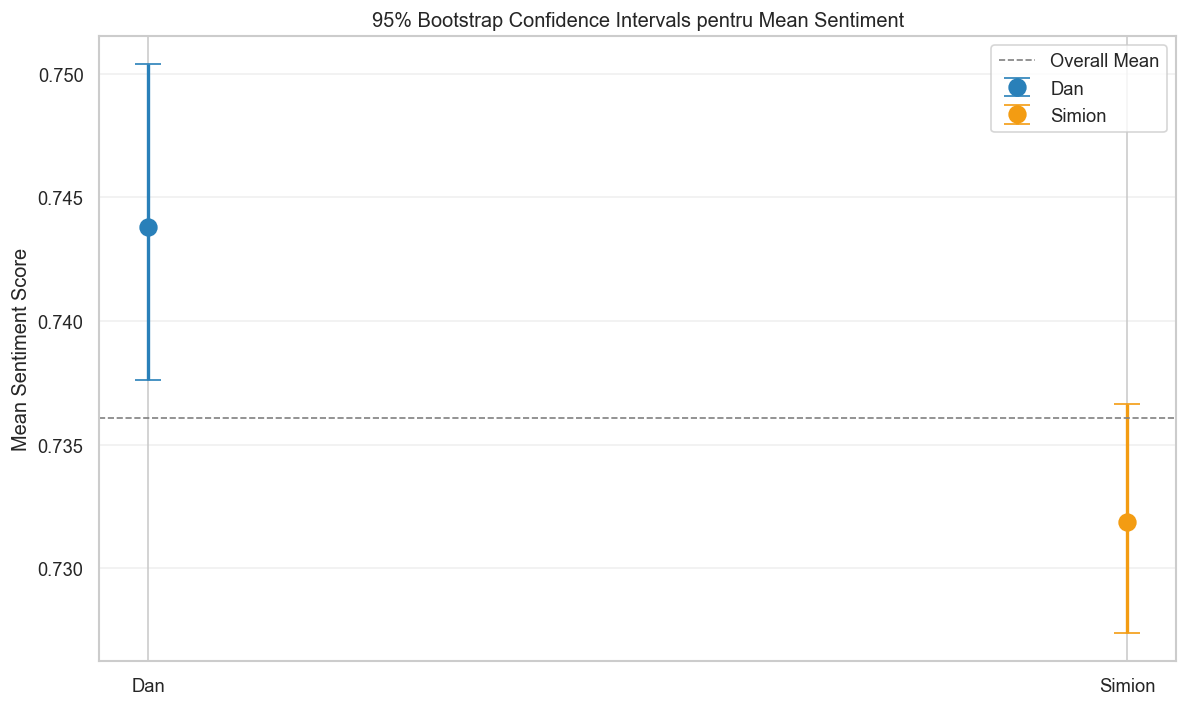

In [7]:
print("\n" + "=" * 70)
print("6.2 TESTE STATISTICE PENTRU RQ2")
print("=" * 70)

# Verificare preliminară

u_stat, p_u, r_rb = None, None, None
chi2, p_chi2, cramers_v = None, None, None
dan_mean, dan_lo, dan_hi = None, None, None
simion_mean, simion_lo, simion_hi = None, None, None
tests_run = False

if dan_count == 0 or simion_count == 0:
    print("\n⚠️  NU SE POT RULA TESTE STATISTICE!")
    print("   Motiv: Unul dintre candidați are 0 comentarii.")
    print("   Continuăm doar cu statisticile descriptive.")
else:
    # Test 1: Mann-Whitney U (sentiment scores)
    print("\n✓ TEST 1: Mann-Whitney U (Sentiment Scores Dan vs Simion)")
    print("   H0: Distribuțiile de sentiment sunt identice")
    print("   H1: Distribuțiile diferă semnificativ\n")

    dan_scores = df_political[df_political['candidate_mentioned'] == 'dan']['sentiment_score']
    simion_scores = df_political[df_political['candidate_mentioned'] == 'simion']['sentiment_score']

    u_stat, p_u = mannwhitneyu(dan_scores, simion_scores, alternative='two-sided')

    # Effect size (rank-biserial correlation)
    n1, n2 = len(dan_scores), len(simion_scores)
    r_rb = 1 - (2 * u_stat) / (n1 * n2)

    print(f"   Dan mean: {dan_scores.mean():.4f} (n={n1:,})")
    print(f"   Simion mean: {simion_scores.mean():.4f} (n={n2:,})")
    print(f"   U statistic: {u_stat:.2f}")
    print(f"   p-value: {p_u:.6f}")
    print(f"   Rank-biserial r: {r_rb:.4f}")
    print(f"   Rezultat: {'✅ SEMNIFICATIV' if p_u < SIGNIFICANCE_LEVEL else '❌ NU SEMNIFICATIV'} (α = {SIGNIFICANCE_LEVEL})")

    if p_u < SIGNIFICANCE_LEVEL:
        higher = 'Dan' if dan_scores.mean() > simion_scores.mean() else 'Simion'
        print(f"   Interpretare: Comentariile despre {higher} sunt semnificativ mai {'pozitive' if higher == 'Dan' else 'negative'}.")

    # Test 2: Chi-square (sentiment labels × candidate)
    print("\n✓ TEST 2: Chi-Pătrat (Sentiment Labels × Candidat)")
    print("   H0: Sentimentul este independent de candidat")
    print("   H1: Sentimentul variază în funcție de candidat\n")

    contingency_table = pd.crosstab(
        df_political['candidate_mentioned'],
        df_political['sentiment_label']
    )

    chi2, p_chi2, dof, expected = chi2_contingency(contingency_table)

    # Cramér's V (effect size)
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

    print(f"   Chi-pătrat: {chi2:.4f}")
    print(f"   p-value: {p_chi2:.6f}")
    print(f"   Grade de libertate: {dof}")
    print(f"   Cramér's V: {cramers_v:.4f}")
    print(f"   Rezultat: {'✅ SEMNIFICATIV' if p_chi2 < SIGNIFICANCE_LEVEL else '❌ NU SEMNIFICATIV'} (α = {SIGNIFICANCE_LEVEL})")

    if p_chi2 < SIGNIFICANCE_LEVEL:
        print(f"   Interpretare: Distribuția sentimentului VARIAZĂ semnificativ între candidați.")

    tests_run = True

    # Test 3: Bootstrap Confidence Intervals
    print("\n✓ TEST 3: Bootstrap 95% CI pentru Mean Sentiment Score")
    print(f"   Număr eșantioane: {BOOTSTRAP_SAMPLES}\n")

    rng = np.random.default_rng(RANDOM_SEED)

    def bootstrap_mean_ci(values, n_boot=BOOTSTRAP_SAMPLES, alpha=0.05):
        values = np.asarray(values, dtype=float)
        boots = [rng.choice(values, size=len(values), replace=True).mean() for _ in range(n_boot)]
        lo = np.quantile(boots, alpha/2)
        hi = np.quantile(boots, 1 - alpha/2)
        return values.mean(), lo, hi

    dan_mean, dan_lo, dan_hi = bootstrap_mean_ci(dan_scores.values)
    simion_mean, simion_lo, simion_hi = bootstrap_mean_ci(simion_scores.values)

    print(f"   Dan: {dan_mean:.4f} [95% CI: {dan_lo:.4f}, {dan_hi:.4f}]")
    print(f"   Simion: {simion_mean:.4f} [95% CI: {simion_lo:.4f}, {simion_hi:.4f}]")

    # Check if CIs overlap
    if dan_hi < simion_lo or simion_hi < dan_lo:
        print(f"   ✅ Intervalele NU se suprapun - diferență semnificativă")
    else:
        print(f"   ⚠️  Intervalele se suprapun")

print("\n" + "=" * 70)
print("6.3 VIZUALIZARE BOOTSTRAP CI")
print("=" * 70)

if dan_count > 0 and simion_count > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    ci_data = pd.DataFrame({
        'Candidat': ['Dan', 'Simion'],
        'Mean': [dan_mean, simion_mean],
        'CI_Low': [dan_lo, simion_lo],
        'CI_High': [dan_hi, simion_hi]
    })

    # FIX: Culori separate pentru fiecare punct
    colors_ci = ['#2980b9', '#f39c12']

    for i, row in ci_data.iterrows():
        ax.errorbar(
            x=row['Candidat'],
            y=row['Mean'],
            yerr=[[row['Mean'] - row['CI_Low']], [row['CI_High'] - row['Mean']]],
            fmt='o',
            capsize=8,
            linewidth=2,
            markersize=10,
            color=colors_ci[i],
            ecolor=colors_ci[i],
            label=row['Candidat']
        )

    ax.set_ylabel('Mean Sentiment Score')
    ax.set_title('95% Bootstrap Confidence Intervals pentru Mean Sentiment')
    overall_mean = df_political['sentiment_score'].mean()
    ax.axhline(overall_mean, color='gray', linestyle='--', linewidth=1, label='Overall Mean')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(DATA_OUTPUT / 'rq2_bootstrap_ci.png', dpi=150, bbox_inches='tight')
    print(f"💾 Grafic salvat: {DATA_OUTPUT / 'rq2_bootstrap_ci.png'}")
    plt.show()
else:
    print("⚠️  Nu există date suficiente pentru vizualizare.")

# 8. Net Sentiment Index

In [8]:
print("\n" + "=" * 70)
print("NET SENTIMENT INDEX (Positive% - Negative%)")
print("=" * 70)

def net_sentiment(subset):
    """Calculează Net Sentiment Index: Positive% - Negative%"""
    vc = subset['sentiment_label'].value_counts(normalize=True)
    return (vc.get('positive', 0) - vc.get('negative', 0)) * 100

# Calculate for each candidate
if dan_count > 0:
    net_dan = net_sentiment(df_political[df_political['candidate_mentioned'] == 'dan'])
    print(f"   Nicușor Dan: {net_dan:+.1f} puncte procentuale")
else:
    net_dan = 0
    print("   Nicușor Dan: N/A (0 comentarii)")

if simion_count > 0:
    net_simion = net_sentiment(df_political[df_political['candidate_mentioned'] == 'simion'])
    print(f"   George Simion: {net_simion:+.1f} puncte procentuale")
else:
    net_simion = 0
    print("   George Simion: N/A (0 comentarii)")

# General comments
general_count = (df['candidate_mentioned'] == 'none').sum()
if general_count > 0:
    net_general = net_sentiment(df[df['candidate_mentioned'] == 'none'])
    print(f"   General/Alte: {net_general:+.1f} puncte procentuale")
else:
    net_general = 0
    print("   General/Alte: N/A (0 comentarii)")

print(f"\n💡 Interpretare:")
print(f"   • Dan are un sentiment net {'POZITIV' if net_dan > 0 else 'NEGATIV'} ({net_dan:+.1f}pp)")
print(f"   • Simion are un sentiment net {'POZITIV' if net_simion > 0 else 'NEGATIV'} ({net_simion:+.1f}pp)")
if dan_count > 0 and simion_count > 0:
    print(f"   • Diferența Dan-Simion: {net_dan - net_simion:+.1f}pp în favoarea lui Dan")



NET SENTIMENT INDEX (Positive% - Negative%)
   Nicușor Dan: -34.2 puncte procentuale
   George Simion: -34.7 puncte procentuale
   General/Alte: -30.7 puncte procentuale

💡 Interpretare:
   • Dan are un sentiment net NEGATIV (-34.2pp)
   • Simion are un sentiment net NEGATIV (-34.7pp)
   • Diferența Dan-Simion: +0.4pp în favoarea lui Dan


# 9. Export Tabele pentru Disertație

In [9]:
print("\n" + "=" * 70)
print("EXPORT TABELE PENTRU DISERTAȚIE")
print("=" * 70)

# Table 1: Sentiment Distribution (2 classes)
table_1 = pd.DataFrame({
    'Sentiment': ['Positive', 'Negative', 'Total'],
    'Count': [
        sentiment_counts.get('positive', 0),
        sentiment_counts.get('negative', 0),
        len(df)
    ],
    'Percentage': [
        sentiment_pct.get('positive', 0),
        sentiment_pct.get('negative', 0),
        100.0
    ]
})

# Table 2: Sentiment by Candidate
table_2_data = []
for cand in ['dan', 'simion']:
    subset = df_political[df_political['candidate_mentioned'] == cand]
    if len(subset) > 0:
        vc = subset['sentiment_label'].value_counts(normalize=True) * 100
        table_2_data.append({
            'Candidat': 'Nicușor Dan' if cand == 'dan' else 'George Simion',
            'Positive %': vc.get('positive', 0),
            'Negative %': vc.get('negative', 0),
            'N': len(subset)
        })
table_2 = pd.DataFrame(table_2_data) if table_2_data else pd.DataFrame()

# Table 3: Statistical Tests
table_3_data = []

if tests_run:
    table_3_data = [
        {'Test': 'Mann-Whitney U', 'Statistic': f'U={u_stat:.0f}', 'p-value': f'{p_u:.6f}', 'Effect Size': f'r={r_rb:.4f}'},
        {'Test': 'Chi-square', 'Statistic': f'χ²={chi2:.2f}', 'p-value': f'{p_chi2:.6f}', 'Effect Size': f'V={cramers_v:.4f}'},
        {'Test': 'Bootstrap CI Dan', 'Statistic': f'Mean={dan_mean:.4f}', 'p-value': 'N/A', 'Effect Size': f'[{dan_lo:.4f}, {dan_hi:.4f}]'},
        {'Test': 'Bootstrap CI Simion', 'Statistic': f'Mean={simion_mean:.4f}', 'p-value': 'N/A', 'Effect Size': f'[{simion_lo:.4f}, {simion_hi:.4f}]'}
    ]
else:
    table_3_data = [
        {'Test': 'Mann-Whitney U', 'Statistic': 'N/A', 'p-value': 'N/A', 'Effect Size': 'Date insuficiente'},
        {'Test': 'Chi-square', 'Statistic': 'N/A', 'p-value': 'N/A', 'Effect Size': 'Date insuficiente'},
        {'Test': 'Bootstrap CI Dan', 'Statistic': 'N/A', 'p-value': 'N/A', 'Effect Size': 'Date insuficiente'},
        {'Test': 'Bootstrap CI Simion', 'Statistic': 'N/A', 'p-value': 'N/A', 'Effect Size': 'Date insuficiente'}
    ]

table_3 = pd.DataFrame(table_3_data)

# Save tables
table_1.to_csv(DATA_OUTPUT / 'table_1_sentiment_distribution.csv', index=False, encoding='utf-8-sig')
print(f"✅ Tabel 1 exportat: {DATA_OUTPUT / 'table_1_sentiment_distribution.csv'}")

if len(table_2) > 0:
    table_2.to_csv(DATA_OUTPUT / 'table_2_sentiment_by_candidate.csv', index=False, encoding='utf-8-sig')
    print(f"✅ Tabel 2 exportat: {DATA_OUTPUT / 'table_2_sentiment_by_candidate.csv'}")

table_3.to_csv(DATA_OUTPUT / 'table_3_statistical_tests.csv', index=False, encoding='utf-8-sig')
print(f"✅ Tabel 3 exportat: {DATA_OUTPUT / 'table_3_statistical_tests.csv'}")

# Save analyzed dataset
df.to_csv(FILE_COMMENTS_ANALYZED, index=False, encoding='utf-8-sig')
print(f"✅ Dataset complet salvat: {FILE_COMMENTS_ANALYZED}")


EXPORT TABELE PENTRU DISERTAȚIE
✅ Tabel 1 exportat: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\dissertation_outputs\table_1_sentiment_distribution.csv
✅ Tabel 2 exportat: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\dissertation_outputs\table_2_sentiment_by_candidate.csv
✅ Tabel 3 exportat: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\dissertation_outputs\table_3_statistical_tests.csv
✅ Dataset complet salvat: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\data\processed\comments_analyzed.csv


# 10. Rezumat RQ1 și RQ2

In [10]:
print("\n" + "=" * 70)
print("REZUMAT RQ1 ȘI RQ2")
print("=" * 70)

print(f"""
╔══════════════════════════════════════════════════════════════════════════╗
║                         REZUMAT ANALIZĂ SENTIMENT                        ║
╠══════════════════════════════════════════════════════════════════════════╣
║ RQ1: Structura Afectivă                                                  ║
║ ─────────────────────                                                    ║
║ • Sentiment predominant: {dominant_sentiment.upper():<12} ({dominant_pct:.1f}%)                        ║
║ • Pozitive: {sentiment_pct.get('positive', 0):>5.1f}%  |  Negative: {sentiment_pct.get('negative', 0):>5.1f}%                      ║
║ • Răspuns: Discursul {'NU este dominat de negativitate' if dominant_sentiment != 'negative' else 'este dominat de negativitate':<35} ║
╠══════════════════════════════════════════════════════════════════════════╣
║ RQ2: Diferențe Dan vs Simion                                             ║
║ ─────────────────────────────                                            ║
║ • Dan comentarii: {dan_count:>10,}                                          ║
║ • Simion comentarii: {simion_count:>8,}                                          ║
║ • Dan mean score: {dan_mean:>7.4f} [{dan_lo:.4f}, {dan_hi:.4f}]                               ║
║ • Simion mean score: {simion_mean:>5.4f} [{simion_lo:.4f}, {simion_hi:.4f}]                           ║
║ • Mann-Whitney U: p = {p_u:<10.6f} {('✅' if p_u < SIGNIFICANCE_LEVEL else '❌'):>3}                  ║
║ • Chi-square: p = {p_chi2:<10.6f} {('✅' if p_chi2 < SIGNIFICANCE_LEVEL else '❌'):>3}                  ║
║ • Net Sentiment: Dan {net_dan:>+6.1f}pp  |  Simion {net_simion:>+6.1f}pp                         ║
╚══════════════════════════════════════════════════════════════════════════╝

📁 FIȘIERE EXPORTATE:
   • 3 tabele CSV pentru disertație
   • 3 grafice PNG
   • Dataset complet cu sentiment adăugat

🎯 URMĂTORUL PAS:
   • 03_topics_polarization.ipynb - BERTopic pentru teme
   • 04_outrage_economy.ipynb - Engagement predictors (RQ3)
   • 05_export_tables.ipynb - Tabele finale LaTeX/Markdown

{"=" * 70}
""")


REZUMAT RQ1 ȘI RQ2

╔══════════════════════════════════════════════════════════════════════════╗
║                         REZUMAT ANALIZĂ SENTIMENT                        ║
╠══════════════════════════════════════════════════════════════════════════╣
║ RQ1: Structura Afectivă                                                  ║
║ ─────────────────────                                                    ║
║ • Sentiment predominant: NEGATIVE     (66.4%)                        ║
║ • Pozitive:  33.6%  |  Negative:  66.4%                      ║
║ • Răspuns: Discursul este dominat de negativitate        ║
╠══════════════════════════════════════════════════════════════════════════╣
║ RQ2: Diferențe Dan vs Simion                                             ║
║ ─────────────────────────────                                            ║
║ • Dan comentarii:      1,825                                          ║
║ • Simion comentarii:    3,343                                          ║
║ • Dan mean sc

# **Notă:** Acest notebook este 100% reproductibil. Toate seed-urile sunt setate la valoarea din `config.py` (RANDOM_SEED = 42).